# Effect of the Number of Security Checkpoints

**Research question:** How does the number of active security checkpoints affect passenger waiting time, congestion, and throughput?

Compare 1, 2, 3, and 4 checkpoints while keeping passenger arrival probability and service duration fixed. Each scenario uses 30 random seeds and runs for 5,000 time steps from an initially empty system.

This experiment changes the number of checkpoints **and their associated internal queues**. Each queue has capacity 10, so total internal waiting capacity is 10, 20, 30, or 40 passengers. It does not isolate checkpoint count at fixed total waiting capacity.

## Setup

Install the project dependencies using `python -m pip install -r requirements.txt`. Select that Python environment as the notebook kernel. Run this notebook from the project root or its `notebooks` directory.

The model is imported from `src`; its implementation is not duplicated here. Restart the kernel and run all cells after changing a model file.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = next(
    (
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "src" / "model.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Start the notebook from the project root or the notebooks directory."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model import AirportSecurityModel

## Experimental Design and Measurement

| Parameter | Setting |
| --- | --- |
| Number of checkpoints | 1, 2, 3, 4 |
| Arrival probability | 0.4 per time step; at most one arrival per step |
| Queue capacity | 10 waiting passengers per checkpoint |
| Service duration | Fixed at 4 time steps |
| Processing-time variation | 0 |
| Simulation length | 5,000 time steps |
| Repetitions | 30, using seeds 0 through 29 |

Each checkpoint has a nominal service capacity of 0.25 passengers per time step. One checkpoint therefore has less capacity than the expected arrival demand of 0.4. Its nominal load ratio is 0.4 / 0.25 = 1.6, so this is an overloaded scenario. Its external queue is expected to grow; a stable finite long-run waiting-time estimate is not expected. With two checkpoints, the nominal load ratio is 0.4 / 0.5 = 0.8.

With fixed service duration, service sampling consumes no random draws in the current model. Reusing a seed therefore produces the same arrival sequence for each checkpoint count in this experiment. This property need not hold when service-duration variation is enabled.

- Waiting time includes external and internal waiting but is reported only for passengers who complete screening before the simulation ends.
- Internal and external queue lengths are measured separately at the end of each time step.
- Throughput rate is completed passengers divided by simulation steps.
- Unfinished passengers include internal waiters, external waiters, and passengers still in service.
- No warm-up period is removed and no drain-down period is added.

In [2]:
checkpoint_counts = [1, 2, 3, 4]
seeds = range(30)
simulation_steps = 5000
base_parameters = {
    "arrival_rate": 0.4,
    "queue_capacity": 10,
    "processing_time": 4,
    "processing_time_variation": 0,
    "simulation_steps": simulation_steps,
}
experiment_results = []

for checkpoint_count in checkpoint_counts:
    for seed in seeds:
        model = AirportSecurityModel(
            **base_parameters,
            num_checkpoints=checkpoint_count,
            seed=seed,
        )
        model.run()

        completed_waits = [
            passenger.waiting_time
            for passenger in model.completed_passengers
        ]
        completed_count = len(model.completed_passengers)
        internal_count = sum(len(queue) for queue in model.queues)
        external_count = len(model.external_waiting)
        in_service_count = sum(
            passenger is not None for passenger in model.in_service
        )
        unfinished_count = internal_count + external_count + in_service_count

        assert len(model.all_passengers) == completed_count + unfinished_count, (
            "Passenger counts are inconsistent."
        )

        experiment_results.append({
            **base_parameters,
            "num_checkpoints": checkpoint_count,
            "total_internal_capacity": checkpoint_count * base_parameters["queue_capacity"],
            "seed": seed,
            "mean_completed_wait": (
                float(np.mean(completed_waits)) if completed_waits else np.nan
            ),
            "mean_internal_queue": float(np.mean(model.queue_length_history)),
            "mean_external_queue": float(np.mean(model.external_waiting_history)),
            "throughput_rate": completed_count / simulation_steps,
            "arrived_passengers": len(model.all_passengers),
            "completed_passengers": completed_count,
            "unfinished_passengers": unfinished_count,
            "final_external_queue": external_count,
            "final_internal_queue": internal_count,
            "final_in_service": in_service_count,
        })

print(f"Completed {len(experiment_results)} simulation runs.")

Completed 120 simulation runs.


## Summary Across Repeated Runs

Each run receives equal weight. The standard deviation of run mean waiting times measures variation between runs; it is neither the standard deviation of individual passenger waiting times nor a confidence interval. Undefined waiting-time means are excluded and the number of valid runs is reported.

In [3]:
summary_results = []

for checkpoint_count in checkpoint_counts:
    runs = [
        result for result in experiment_results
        if result["num_checkpoints"] == checkpoint_count
    ]
    waits = np.array([run["mean_completed_wait"] for run in runs])
    valid_waits = waits[np.isfinite(waits)]

    summary_results.append({
        "num_checkpoints": checkpoint_count,
        "total_internal_capacity": checkpoint_count * base_parameters["queue_capacity"],
        "runs": len(runs),
        "valid_wait_runs": len(valid_waits),
        "mean_wait": float(np.mean(valid_waits)) if len(valid_waits) else np.nan,
        "sd_wait": (
            float(np.std(valid_waits, ddof=1)) if len(valid_waits) > 1 else np.nan
        ),
        "mean_internal_queue": float(np.mean([
            run["mean_internal_queue"] for run in runs
        ])),
        "mean_external_queue": float(np.mean([
            run["mean_external_queue"] for run in runs
        ])),
        "mean_throughput_rate": float(np.mean([
            run["throughput_rate"] for run in runs
        ])),
        "mean_unfinished_passengers": float(np.mean([
            run["unfinished_passengers"] for run in runs
        ])),
        "mean_final_external_queue": float(np.mean([
            run["final_external_queue"] for run in runs
        ])),
    })

for result in summary_results:
    print(f"Checkpoints: {result['num_checkpoints']}")
    print(f"  Total internal waiting capacity: {result['total_internal_capacity']}")
    print(f"  Runs with completed passengers: {result['valid_wait_runs']}/{result['runs']}")
    print(f"  Completed-passenger mean wait: {result['mean_wait']:.2f} time steps")
    print(f"  SD of run mean waits: {result['sd_wait']:.2f} time steps")
    print(f"  Mean internal queue: {result['mean_internal_queue']:.2f} passengers")
    print(f"  Mean external queue: {result['mean_external_queue']:.2f} passengers")
    print(f"  Mean throughput: {result['mean_throughput_rate']:.3f} passengers per time step")
    print(f"  Mean unfinished passengers at end: {result['mean_unfinished_passengers']:.2f}")
    print(f"  Mean external queue at end: {result['mean_final_external_queue']:.2f}")
    print()

Checkpoints: 1
  Total internal waiting capacity: 10
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 932.85 time steps
  SD of run mean waits: 35.40 time steps
  Mean internal queue: 9.92 passengers
  Mean external queue: 363.34 passengers
  Mean throughput: 0.250 passengers per time step
  Mean unfinished passengers at end: 748.30
  Mean external queue at end: 737.30

Checkpoints: 2
  Total internal waiting capacity: 20
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 1.96 time steps
  SD of run mean waits: 0.25 time steps
  Mean internal queue: 0.78 passengers
  Mean external queue: 0.00 passengers
  Mean throughput: 0.399 passengers per time step
  Mean unfinished passengers at end: 2.37
  Mean external queue at end: 0.00

Checkpoints: 3
  Total internal waiting capacity: 30
  Runs with completed passengers: 30/30
  Completed-passenger mean wait: 0.12 time steps
  SD of run mean waits: 0.02 time steps
  Mean internal queue: 0.05 passe

## Waiting-Time Comparison

The left panel includes all four checkpoint counts. The right panel is a separate linear-scale view of counts 2–4, with a much smaller vertical range; it does not include the overloaded one-checkpoint case. Both vertical axes start at zero.

Bars show the mean of run mean waiting times, with error bars of **one standard deviation between runs**. These are not confidence intervals. Waiting statistics cover only completed passengers. The one-checkpoint mean depends strongly on the observation horizon and excludes the unfinished backlog.

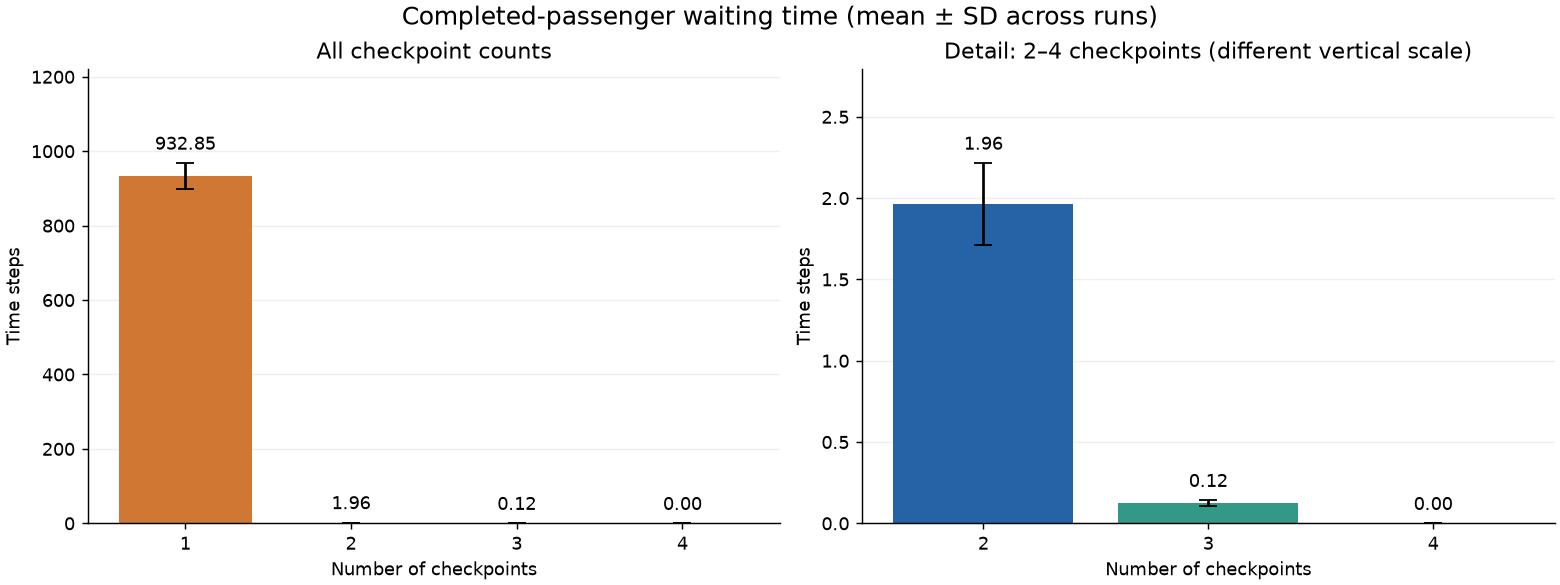

In [4]:
counts = [result["num_checkpoints"] for result in summary_results]
waits = np.array([result["mean_wait"] for result in summary_results])
errors = np.array([result["sd_wait"] for result in summary_results])
colors = ["#CE7833", "#2563A6", "#349889", "#7563A3"]

with plt.rc_context({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False}):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
    fig.suptitle("Completed-passenger waiting time (mean ± SD across runs)", fontsize=14)
    for ax, start, title in [
        (axes[0], 0, "All checkpoint counts"),
        (axes[1], 1, "Detail: 2–4 checkpoints (different vertical scale)"),
    ]:
        bars = ax.bar(counts[start:], waits[start:], yerr=errors[start:],
                      capsize=5, color=colors[start:])
        ax.bar_label(bars, fmt="%.2f", padding=5)
        ax.set(title=title, xlabel="Number of checkpoints", ylabel="Time steps")
        ax.set_xticks(counts[start:])
        ax.set_ylim(0, max(ax.get_ylim()[1] * 1.2, 0.1))
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
    plt.show()

## Queues, Throughput, and Unfinished Passengers

Each panel shows the mean across 30 runs, without error bars. Queue lengths are time averages; unfinished counts are measured at the end. The four panels use different vertical scales and label small or zero values directly.

Queue capacity remains 10 **per checkpoint**, so total internal waiting capacity rises with checkpoint count. The throughput reference line is expected arrival demand, not a confidence interval.

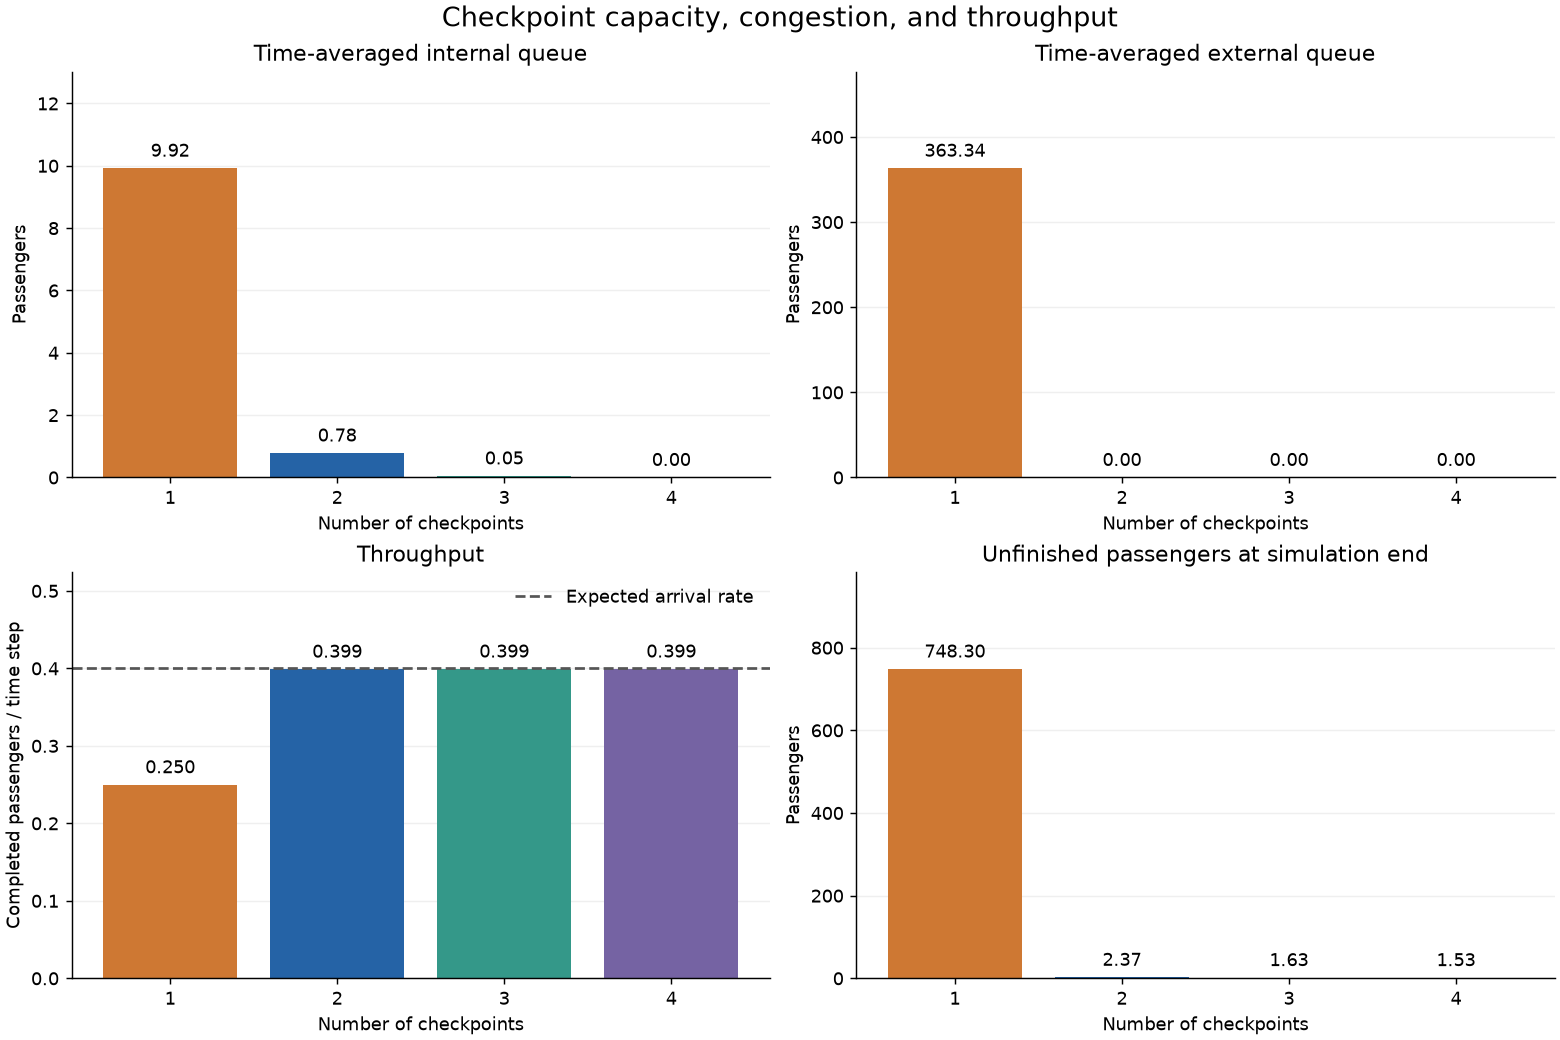

In [5]:
panels = [
    ("mean_internal_queue", "Time-averaged internal queue", "Passengers"),
    ("mean_external_queue", "Time-averaged external queue", "Passengers"),
    ("mean_throughput_rate", "Throughput", "Completed passengers / time step"),
    ("mean_unfinished_passengers", "Unfinished passengers at simulation end", "Passengers"),
]

with plt.rc_context({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False}):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
    fig.suptitle("Checkpoint capacity, congestion, and throughput", fontsize=15)

    for ax, (key, title, unit) in zip(axes.flat, panels):
        values = [result[key] for result in summary_results]
        bars = ax.bar(counts, values, color=colors)
        ax.bar_label(bars, fmt="%.3f" if key == "mean_throughput_rate" else "%.2f", padding=4)
        if key == "mean_throughput_rate":
            ax.axhline(base_parameters["arrival_rate"], color="#555555", linestyle="--",
                       label="Expected arrival rate")
            ax.legend(frameon=False)
        ax.set(title=title, xlabel="Number of checkpoints", ylabel=unit)
        ax.set_xticks(counts)
        ax.set_ylim(0, max(ax.get_ylim()[1] * 1.25, 0.1))
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
    plt.show()

### Reading the Comparisons

In the default experiment, one checkpoint completes about 0.250 passengers per step and leaves about 748 passengers unfinished at the end of a run. Two checkpoints increase throughput to about 0.399 and reduce mean completed-passenger waiting time from about 933 to 1.96 steps. Three and four further reduce waiting, while throughput remains limited by arrival demand. The one-checkpoint value of about 933 steps is a completed-passenger statistic for this observation horizon, not a stable long-run mean or a mean covering the unfinished backlog.

The zero waiting time with four checkpoints follows from at most one arrival per step and fixed four-step service. It is specific to these assumptions. Saved numerical observations should be updated if the experiment parameters change.

## Interpretation and Limitations

Compare throughput with waiting and unfinished-passenger counts. Once service capacity is sufficient for the arrival demand, additional checkpoints may reduce waiting without substantially increasing throughput.

The one-checkpoint scenario is overloaded under these assumptions. Its reported waiting-time mean covers only passengers who finish within 5,000 steps and omits the growing backlog. It is not a steady-state mean or a mean over all arriving passengers, and its value depends on the observation horizon. Extending the run or removing an initial warm-up period cannot resolve demand exceeding service capacity. Stopping arrivals and draining the system would instead measure waiting for a finite arrival cohort; it would not demonstrate steady state under overload.

The internal queues are bounded; external waiting is not. A plateau in internal queue length alone does not demonstrate system stability. Total internal waiting capacity also increases with checkpoint count, so the scenarios represent adding staffed checkpoints with their associated queues.

Four checkpoints can serve every possible arrival immediately under the specific assumptions of at most one arrival per step, fixed four-step service, and completion processing before new arrivals. Zero waiting in this case is a consequence of the model assumptions, not a general prediction for real airports.

These experiments begin empty and retain the initial transient. Differences are descriptive; no statistical-significance test is performed here.